# 07_define_load_and_break_refined.ipynb

## Aim
This notebook defines a first-pass operational framework for **load** and **break** in the yeast interactome under genetic perturbation.

## Why this notebook?
Previous analyses showed that:
- chaperones and their interacting partners form strongly small-world-like neighborhoods,
- chaperones are concentrated in specific modules,
- removing chaperones destabilizes certain modules,
- perturbations propagate through specific module-to-module relationships.

These results suggest that chaperones function as **local proteostasis stabilizers**. The next question is whether modules under greater perturbation burden also show greater structural loss.

## Working definitions used here
### Load
For each chaperone under each deletion:
- measure the mean absolute deviation of neighboring protein fold changes from baseline

Then aggregate this to the module level.

### Break
For each module under each deletion:
- remove strongly perturbed measured proteins
- quantify fragmentation as **LCC drop** relative to the module’s measurable baseline

This notebook focuses only on the load and break metrics that gave interpretable results.

In [3]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [4]:
# ============================================================
# CELL 3: HELPER FUNCTIONS
# ============================================================

def compute_chaperone_load_for_one_deletion(
    deletion_fc_series,
    G,
    chaperone_nodes,
    fc_threshold=0.5
):
    """
    Compute chaperone-level load for one deletion profile.

    Fold changes are assumed to be ratio-scale with baseline = 1.
    """
    rows = []

    for chap in chaperone_nodes:
        if chap not in G:
            continue

        neighbors = list(G.neighbors(chap))
        vals = deletion_fc_series.reindex(neighbors).dropna()

        if len(vals) == 0:
            rows.append({
                "chaperone": chap,
                "n_neighbors": len(neighbors),
                "n_neighbors_measured": 0,
                "mean_abs_change": np.nan,
                "perturbed_fraction": np.nan
            })
            continue

        abs_changes = (vals.astype(float) - 1.0).abs()

        rows.append({
            "chaperone": chap,
            "n_neighbors": len(neighbors),
            "n_neighbors_measured": len(vals),
            "mean_abs_change": abs_changes.mean(),
            "perturbed_fraction": (abs_changes >= fc_threshold).mean()
        })

    return pd.DataFrame(rows)


def summarize_module_load(chaperone_load_df, chaperone_to_module):
    """
    Aggregate chaperone load to the module level.
    """
    df = chaperone_load_df.copy()
    df["module"] = df["chaperone"].map(chaperone_to_module)
    df = df[df["module"].notna()].copy()

    summary = (
        df.groupby("module")
        .agg(
            n_chaperones=("chaperone", "count"),
            mean_of_means=("mean_abs_change", "mean"),
            mean_perturbed_fraction=("perturbed_fraction", "mean")
        )
        .reset_index()
    )
    return summary


def compute_lcc_break_metrics(G_module, baseline_n_nodes):
    """
    Compute simple module break metrics, focusing on fragmentation.
    """
    if baseline_n_nodes == 0:
        return {
            "module_size": 0,
            "lcc_size": 0,
            "lcc_fraction": np.nan,
            "n_components": 0
        }

    if G_module.number_of_nodes() == 0:
        return {
            "module_size": 0,
            "lcc_size": 0,
            "lcc_fraction": 0.0,
            "n_components": 0
        }

    comps = list(nx.connected_components(G_module))
    lcc_size = max(len(c) for c in comps)

    return {
        "module_size": G_module.number_of_nodes(),
        "lcc_size": lcc_size,
        "lcc_fraction": lcc_size / baseline_n_nodes,
        "n_components": len(comps)
    }

In [5]:
## Load data

#This section loads:
#- the interactome graph
#- chaperone annotations
#- community assignments
#- the cleaned perturbation proteomics matrix

# ============================================================
# CELL 5: LOAD DATA
# ============================================================

nodes_path = "../../18-finalize/processed-data/20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
community_map_path = "../../18-finalize/processed-data/community_map.pkl"
proteome_matrix_path = "../../18-finalize/processed-data/yeast5k_fc_cleaned.pkl"
edges_path = "../../0-download-inputs/data-files/The_Yeast_Interactome_edges.csv"

nodes_df = pd.read_pickle(nodes_path)
community_map = pd.read_pickle(community_map_path)
proteome_df = pd.read_pickle(proteome_matrix_path)
edges_df = pd.read_csv(edges_path)

# identify chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)
nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperone_nodes = set(nodes_df.loc[nodes_df["is_chaperone"], "node"])

# build graph
valid_nodes = set(nodes_df["node"])
edges_clean = edges_df[["source", "target"]].dropna().copy()
edges_clean = edges_clean[
    edges_clean["source"].isin(valid_nodes) &
    edges_clean["target"].isin(valid_nodes)
]
edges_clean = edges_clean[edges_clean["source"] != edges_clean["target"]]

G = nx.from_pandas_edgelist(edges_clean, source="source", target="target", create_using=nx.Graph())
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

# keep only chaperones in graph
chaperone_nodes = chaperone_nodes.intersection(G_lcc.nodes())

# mappings
chaperone_to_module = {c: community_map.get(c, None) for c in chaperone_nodes}
modules = sorted(set(community_map.values()))

print("Proteome matrix shape:", proteome_df.shape)
print("Number of chaperones in LCC:", len(chaperone_nodes))
print("Number of modules:", len(modules))

Proteome matrix shape: (2510, 1850)
Number of chaperones in LCC: 65
Number of modules: 30


In [6]:
## Define measurable module baselines

#Break should be defined relative to the subset of each module that is actually represented in the proteomics matrix, not relative to the full interactome module.

# ============================================================
# CELL 7: MEASURABLE BASELINE PER MODULE
# ============================================================

measured_proteins = set(proteome_df.columns).intersection(set(G_lcc.nodes()))

baseline_rows = []

for m in modules:
    module_nodes = [n for n, cm in community_map.items() if cm == m and n in G_lcc.nodes()]
    module_measured = [n for n in module_nodes if n in measured_proteins]

    G_module_measured = G_lcc.subgraph(module_measured).copy()
    metrics = compute_lcc_break_metrics(G_module_measured, baseline_n_nodes=len(module_measured))

    baseline_rows.append({
        "module": m,
        "baseline_measured_nodes": len(module_measured),
        "baseline_lcc_fraction": metrics["lcc_fraction"],
        "baseline_lcc_size": metrics["lcc_size"],
        "baseline_n_components": metrics["n_components"]
    })

baseline_module_metrics_df = pd.DataFrame(baseline_rows)
baseline_module_metrics_df.head()

,module,baseline_measured_nodes,baseline_lcc_fraction,baseline_lcc_size,baseline_n_components
0,0,15,0.066667,1,15
1,1,2,0.500000,1,2
2,2,2,0.500000,1,2
3,3,4,0.250000,1,4
4,4,2,0.500000,1,2


In [7]:

# ============================================================
# CELL 8: COVERAGE SUMMARY
# ============================================================

coverage_rows = []

for m in modules:
    module_nodes = [n for n, cm in community_map.items() if cm == m and n in G_lcc.nodes()]
    module_measured = [n for n in module_nodes if n in measured_proteins]

    coverage_rows.append({
        "module": m,
        "n_module_nodes": len(module_nodes),
        "n_measured_nodes": len(module_measured),
        "coverage_fraction": len(module_measured) / len(module_nodes) if len(module_nodes) > 0 else np.nan
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values("coverage_fraction", ascending=False)
coverage_df.head(15)

,module,n_module_nodes,n_measured_nodes,coverage_fraction
15,15,10,1,0.100000
11,11,43,1,0.023256
0,0,1060,15,0.014151
8,8,82,1,0.012195
3,3,453,4,0.008830
5,5,275,2,0.007273
4,4,331,2,0.006042
2,2,520,2,0.003846
1,1,636,2,0.003145
19,19,6,0,0.000000


In [8]:
# ============================================================
# CELL 10: COMPUTE MODULE -LEVEL LOAD ACROSS DELETIONS
# ============================================================

valid_deletions = [orf for orf in proteome_df.index if orf in community_map]

load_rows = []

for deletion_orf in valid_deletions:
    deletion_fc = proteome_df.loc[deletion_orf]

    chap_load_df = compute_chaperone_load_for_one_deletion(
        deletion_fc_series=deletion_fc,
        G=G_lcc,
        chaperone_nodes=chaperone_nodes,
        fc_threshold=0.5
    )

    module_load_df = summarize_module_load(chap_load_df, chaperone_to_module)
    module_load_df["deletion_orf"] = deletion_orf
    module_load_df["deletion_module"] = community_map.get(deletion_orf)

    load_rows.append(module_load_df)

module_load_all_df = pd.concat(load_rows, ignore_index=True)
module_load_all_df.head()

,module,n_chaperones,mean_of_means,mean_perturbed_fraction,deletion_orf,deletion_module
0,0,43,0.352427,0.285714,YAL002W,1
1,1,2,NaN,NaN,YAL002W,1
2,2,5,0.033747,0.000000,YAL002W,1
3,3,1,NaN,NaN,YAL002W,1
4,4,8,0.291585,0.000000,YAL002W,1


In [9]:
## Compute module break across deletions

#A module is considered structurally retained under a deletion only through its measured proteins that remain close to baseline.
#This is a first-pass approximation of local break.

# ============================================================
# CELL 12: COMPUTE BREAK ACROSS DELETIONS
# ============================================================

fc_break_threshold = 0.25

break_rows = []

for deletion_orf in valid_deletions:
    deletion_fc = proteome_df.loc[deletion_orf]

    for m in modules:
        module_nodes = [n for n, cm in community_map.items() if cm == m and n in G_lcc.nodes()]
        module_measured = [n for n in module_nodes if n in measured_proteins]

        if len(module_measured) == 0:
            continue

        abs_changes = (deletion_fc.reindex(module_measured).astype(float) - 1.0).abs()
        retained_nodes = [n for n, ac in abs_changes.items() if pd.notna(ac) and ac < fc_break_threshold]

        G_retained = G_lcc.subgraph(retained_nodes).copy()
        metrics = compute_lcc_break_metrics(G_retained, baseline_n_nodes=len(module_measured))

        metrics["module"] = m
        metrics["deletion_orf"] = deletion_orf
        metrics["deletion_module"] = community_map.get(deletion_orf)
        metrics["baseline_measured_nodes"] = len(module_measured)

        break_rows.append(metrics)

module_break_all_df = pd.DataFrame(break_rows)
module_break_all_df.head()

,module_size,lcc_size,lcc_fraction,n_components,module,deletion_orf,deletion_module,baseline_measured_nodes
0,8,1,0.066667,8,0,YAL002W,1,15
1,0,0,0.000000,0,1,YAL002W,1,2
2,2,1,0.500000,2,2,YAL002W,1,2
3,4,1,0.250000,4,3,YAL002W,1,4
4,0,0,0.000000,0,4,YAL002W,1,2


In [10]:
# ============================================================
# CELL 14: MERGE LOAD AND BREAK
# ============================================================

load_break_df = module_load_all_df.merge(
    module_break_all_df,
    on=["module", "deletion_orf", "deletion_module"],
    how="inner"
)

load_break_df = load_break_df.merge(
    baseline_module_metrics_df[["module", "baseline_lcc_fraction", "baseline_measured_nodes"]],
    on="module",
    how="left"
)

load_break_df["lcc_drop"] = load_break_df["baseline_lcc_fraction"] - load_break_df["lcc_fraction"]

load_break_df.head()

,module,n_chaperones,mean_of_means,mean_perturbed_fraction,deletion_orf,deletion_module,module_size,lcc_size,lcc_fraction,n_components,baseline_measured_nodes_x,baseline_lcc_fraction,baseline_measured_nodes_y,lcc_drop
0,0,43,0.352427,0.285714,YAL002W,1,8,1,0.066667,8,15,0.066667,15,0.0
1,1,2,NaN,NaN,YAL002W,1,0,0,0.000000,0,2,0.500000,2,0.5
2,2,5,0.033747,0.000000,YAL002W,1,2,1,0.500000,2,2,0.500000,2,0.0
3,3,1,NaN,NaN,YAL002W,1,4,1,0.250000,4,4,0.250000,4,0.0
4,4,8,0.291585,0.000000,YAL002W,1,0,0,0.000000,0,2,0.500000,2,0.5


In [11]:
# ============================================================
# CELL 16: GLOBAL load–break CORRELATION TESTS
# ============================================================

corr_rows = []

for x in ["mean_of_means", "mean_perturbed_fraction"]:
    sub = load_break_df[[x, "lcc_drop"]].dropna()
    rho, p = spearmanr(sub[x], sub["lcc_drop"])

    corr_rows.append({
        "load_metric": x,
        "break_metric": "lcc_drop",
        "spearman_rho": rho,
        "p_value": p,
        "n": len(sub)
    })

corr_results_df = pd.DataFrame(corr_rows)
corr_results_df

,load_metric,break_metric,spearman_rho,p_value,n
0,mean_of_means,lcc_drop,0.201349,1.012075e-69,7530
1,mean_perturbed_fraction,lcc_drop,0.060813,1.283956e-07,7530


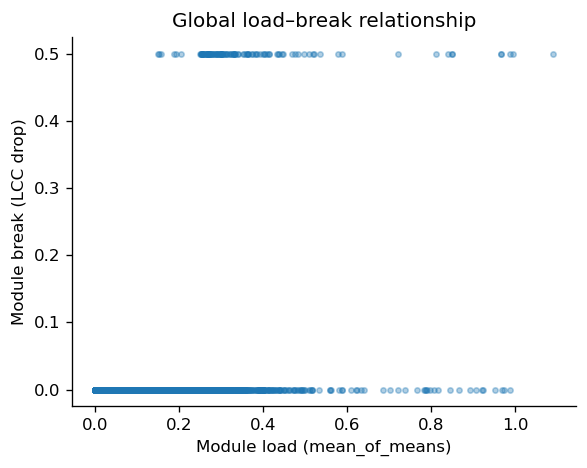

In [12]:
# ============================================================
# CELL 17: GLOBAL SCATTER PLOT
# ============================================================

plt.figure(figsize=(5, 4))
sub = load_break_df[["mean_of_means", "lcc_drop"]].dropna()
plt.scatter(sub["mean_of_means"], sub["lcc_drop"], alpha=0.35, s=10)
plt.xlabel("Module load (mean_of_means)")
plt.ylabel("Module break (LCC drop)")
plt.title("Global load–break relationship")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CELL 19: CHAPERONE-RICH MODULE ANALYSIS
# ============================================================

chaperone_modules = [0, 4, 7]

chap_df = load_break_df[load_break_df["module"].isin(chaperone_modules)].copy()

chap_corr_rows = []

for x in ["mean_of_means", "mean_perturbed_fraction"]:
    sub = chap_df[[x, "lcc_drop"]].dropna()
    rho, p = spearmanr(sub[x], sub["lcc_drop"])

    chap_corr_rows.append({
        "load_metric": x,
        "break_metric": "lcc_drop",
        "spearman_rho": rho,
        "p_value": p,
        "n": len(sub)
    })

chap_corr_results_df = pd.DataFrame(chap_corr_rows)
chap_corr_results_df

,load_metric,break_metric,spearman_rho,p_value,n
0,mean_of_means,lcc_drop,0.232936,7.856596e-63,5020
1,mean_perturbed_fraction,lcc_drop,0.057843,4.119217e-05,5020


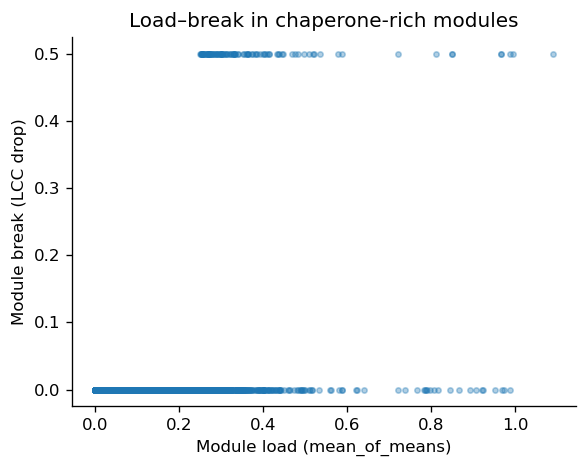

In [14]:
# ============================================================
# CELL 20: CHAPERONE-RICH SCATTER
# ============================================================

plt.figure(figsize=(5, 4))
sub = chap_df[["mean_of_means", "lcc_drop"]].dropna()
plt.scatter(sub["mean_of_means"], sub["lcc_drop"], alpha=0.35, s=10)
plt.xlabel("Module load (mean_of_means)")
plt.ylabel("Module break (LCC drop)")
plt.title("Load–break in chaperone-rich modules")
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL 22: HIGH VS LOW LOAD
# We compare the highest-load and lowest-load perturbations within chaperone-rich modules
# ============================================================

comparison_rows = []

for m in chaperone_modules:
    sub = load_break_df[load_break_df["module"] == m].dropna(subset=["mean_of_means", "lcc_drop"]).copy()

    if len(sub) < 20:
        continue

    q1 = sub["mean_of_means"].quantile(0.25)
    q3 = sub["mean_of_means"].quantile(0.75)

    low = sub[sub["mean_of_means"] <= q1]
    high = sub[sub["mean_of_means"] >= q3]

    if len(low) < 5 or len(high) < 5:
        continue

    stat, p = mannwhitneyu(high["lcc_drop"], low["lcc_drop"], alternative="two-sided")

    comparison_rows.append({
        "module": m,
        "high_load_mean_lcc_drop": high["lcc_drop"].mean(),
        "low_load_mean_lcc_drop": low["lcc_drop"].mean(),
        "p_value": p,
        "n_high": len(high),
        "n_low": len(low)
    })

high_low_df = pd.DataFrame(comparison_rows)
high_low_df

,module,high_load_mean_lcc_drop,low_load_mean_lcc_drop,p_value,n_high,n_low
0,0,0.000000,0.0,1.000000e+00,628,628
1,4,0.084395,0.0,5.599944e-27,628,628


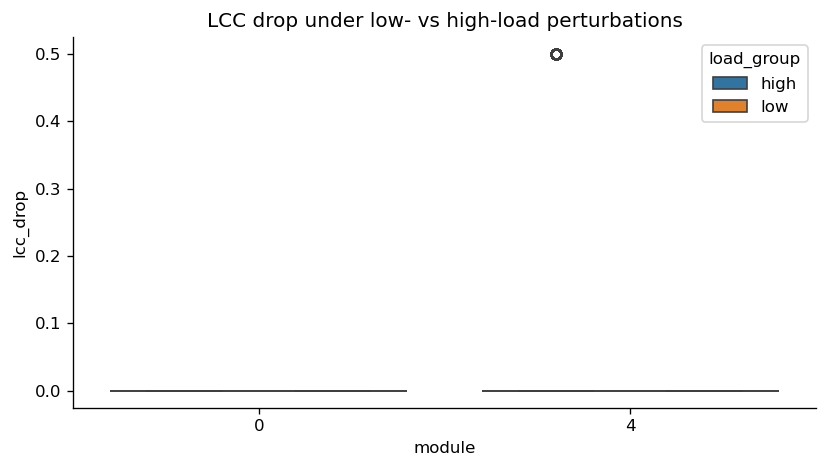

In [16]:
# ============================================================
# CELL 23: BOXPLOT FOR CHAPERONE-RICH MODULES
# ============================================================

plot_rows = []

for m in chaperone_modules:
    sub = load_break_df[load_break_df["module"] == m].dropna(subset=["mean_of_means", "lcc_drop"]).copy()
    if len(sub) < 20:
        continue

    q1 = sub["mean_of_means"].quantile(0.25)
    q3 = sub["mean_of_means"].quantile(0.75)

    sub["load_group"] = "mid"
    sub.loc[sub["mean_of_means"] <= q1, "load_group"] = "low"
    sub.loc[sub["mean_of_means"] >= q3, "load_group"] = "high"

    sub = sub[sub["load_group"].isin(["low", "high"])].copy()
    plot_rows.append(sub[["module", "load_group", "lcc_drop"]])

plot_df = pd.concat(plot_rows, ignore_index=True)

plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df, x="module", y="lcc_drop", hue="load_group")
plt.title("LCC drop under low- vs high-load perturbations")
plt.tight_layout()
plt.show()

A first-pass attempt to operationalize chaperone load and module break using the genetic perturbation proteome atlas showed that perturbation burden can be quantified, but module-level structural break could not be robustly estimated because proteomic coverage of interactome modules was too sparse and disconnected. In most modules, only a very small fraction of proteins was measured, and the measurable subgraphs were already structurally fragmented at baseline. Therefore, this dataset is better suited for activity- and compensation-based analyses than for graph-structural break analysis.